#### chair의 이미지 해상도 통일하여 적용하기

In [2]:
from PIL import Image
import numpy as np

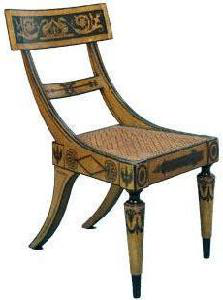

In [6]:
# chair의 1번 이미지
img = Image.open("../Data/chair/image_0001.jpg")
img

In [7]:
# 배열 크기 확인
np.array(img).shape

(300, 223, 3)

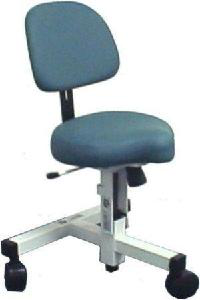

In [8]:
# chair 1번 이미지
img = Image.open("../Data/chair/image_0002.jpg")
img

In [9]:
np.array(img).shape

(300, 200, 3)

> Image의 해상도가 일정하지 않음                 
전체 이미지의 해상도의 평균값을 가지고 적용해보자

### chair의 전체 이미지 평균 해상도 구하기

In [10]:
import glob

In [15]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob("../Data/chair/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

for file in sorted(glob.glob("../Data/laptop/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

In [16]:
print('너비 평균 해상도 :', np.mean(widthRatio))
print('높이 평균 해상도 :', np.mean(heightRatio))

너비 평균 해상도 : 262.34166666666664
높이 평균 해상도 : 282.2083333333333


> 너비 : 264, 높이 : 284로 정함

----
#### chair 이미지 해상도 및 흑백 이미지 변경

In [18]:
i = 1
for file in sorted(glob.glob("../Data/chair/*.jpg")):
    img = Image.open(file)
    imgResize = img.resize((264, 284), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f"../Data/chairNew/image_{i:02}.jpg", "JPEG")
    i+=1

#### Laptop 이미지 해상도 및 흑백 이미지 변경

In [19]:
i = 1
for file in sorted(glob.glob("../Data/laptop/*.jpg")):
    img = Image.open(file)
    imgResize = img.resize((264, 284), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f"../Data/laptopNew/image_{i:02}.jpg", "JPEG")
    i+=1

----
#### chair image를 Numpy로 변경하기

In [20]:
number_of_data = 60
img_width_size = 264
img_height_size = 284

In [24]:
chairData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
chairData.shape

(60, 284, 264)

In [29]:
i=0
for file in sorted(glob.glob("../Data/chairNew/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    chairData[i,:,:] = img
    i+=1
chairData.shape

(60, 284, 264)

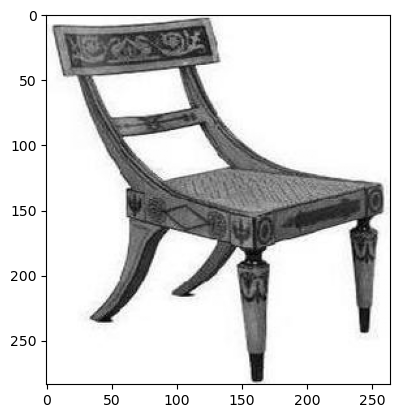

In [33]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(chairData[0].reshape(284, 264), cmap='gray')
plt.show()

#### laptop Image를 Numpy배열로 변경하기

In [35]:
number_of_data = 60
img_width_size = 264
img_height_size = 284

In [36]:
laptopData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
laptopData.shape

(60, 284, 264)

In [37]:
i=0
for file in sorted(glob.glob("../Data/laptopNew/*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    laptopData[i,:,:] = img
    i+=1
laptopData.shape

(60, 284, 264)

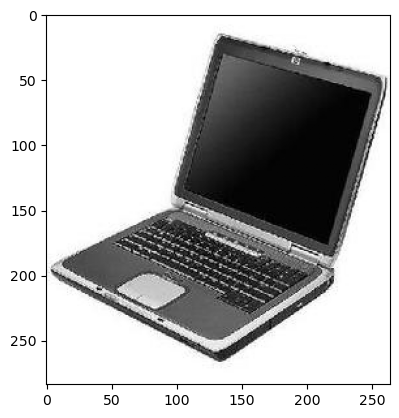

In [41]:
plt.imshow(laptopData[0].reshape(284, 264), cmap='gray')
plt.show()

----
#### Train Data로 합치기

In [42]:
train = np.concatenate(
    [chairData, laptopData]
)
train.shape

(120, 284, 264)

#### Target data 만들기

In [43]:
target = np.concatenate(
    [np.zeros(60), np.ones(60)]
)
target.shape

(120,)

----
#### CNN으로 정확도 측정하기
- 정규화 및 채널 추가
- Train과 Test 분리
- CNN 만들기
- 시각화
- 평가(evaluate로 Train과 Test 평가)

In [ ]:
train = train.reshape(-1, img_height_size, img_width_size, 1) / 255.0
train.shape

(120, 284, 264, 1)

In [58]:
from sklearn.model_selection import train_test_split

In [55]:
# Train과 Test 분리
trainData, testData, trainTarget, testTarget = \
    train_test_split(   
        train,
        target,
        test_size = 0.2,    
        random_state=42
    )

In [56]:
print(trainData.shape)
print(testData.shape)
print(trainTarget.shape)
print(testTarget.shape)

(96, 284, 264, 1)
(24, 284, 264, 1)
(96,)
(24,)


In [59]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [91]:
# -------------------------------------------------------------
# 1. CNN 모델 구성 (합성곱 신경망)
# -------------------------------------------------------------
model = keras.Sequential()

model.add(
    Input(shape=(img_height_size, img_width_size, 1))
)

model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation='relu',
        padding='same'
    )
)

model.add(
    keras.layers.MaxPooling2D(2)
)

model.add(
    keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation='relu',
        padding='same'
    )
)

model.add(
    keras.layers.MaxPooling2D(2)
)

model.add(
    keras.layers.Flatten()
)

model.add(
    keras.layers.Dense(100, activation='relu') # 은닉층
)

# model.add(
#     keras.layers.Dropout(0.5)
# )

model.add(
    keras.layers.Dense(
        1,
        activation='sigmoid', # 이중분류
    )
)

model.summary()


# [Feature Extraction 단계] 이미지의 공간적 특징 추출
# Conv2D: 32개의 3x3 필터를 사용해 특징을 찾고, ReLU 활성화 함수 적용
# model_cnn.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(284, 264, 1)))
# model_cnn.add(layers.MaxPooling2D((2, 2))) # 이미지 크기를 줄여 핵심만 남김 (다운샘플링)

# model_cnn.add(layers.Conv2D(64, (3, 3), activation='relu'))
# model_cnn.add(layers.MaxPooling2D((2, 2)))

# model_cnn.add(layers.Conv2D(64, (3, 3), activation='relu'))

# # [Classification 단계] 추출된 특징을 바탕으로 다중 분류 진행
# model_cnn.add(layers.Flatten()) # 추출된 2차원 특징 맵들을 1차원으로 쫙 펼치기
# model_cnn.add(layers.Dense(64, activation='relu'))
# model_cnn.add(layers.Dropout(0.2)) # 과적합 방지

# # 최종 출력층 (클래스 개수 1개, sigmoid)
# model_cnn.add(layers.Dense(1, activation='sigmoid'))

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 284, 264, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 142, 132, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 142, 132, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 71, 66, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 299904)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │    29,990,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,009,417 (114.48 MB)

 Trainable params: 30,009,417 (114.48 MB)

 Non-trainable params: 0 (0.00 B)

In [85]:
# -------------------------------------------------------------
# 2. 모델 컴파일
# -------------------------------------------------------------
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_cnn_chair&labtop_model.keras")

early_stopping_cb= keras.callbacks.EarlyStopping(
                    patience=7,
                    restore_best_weights=True                  
)

In [86]:
# -------------------------------------------------------------
# 3. 모델 학습 (validation 데이터 활용)
# -------------------------------------------------------------
history = model.fit(
    trainData, 
    trainTarget, 
    epochs=50,                
    validation_data=(testData, testTarget),
    callbacks = [checkpoint_cb, early_stopping_cb],
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4479 - loss: 5.3474 - val_accuracy: 0.4583 - val_loss: 4.0098
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5208 - loss: 1.8090 - val_accuracy: 0.5417 - val_loss: 0.8843
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.4896 - loss: 0.9008 - val_accuracy: 0.7917 - val_loss: 0.6497
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7500 - loss: 0.6110 - val_accuracy: 0.7917 - val_loss: 0.5983
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8229 - loss: 0.4683 - val_accuracy: 0.6667 - val_loss: 0.6062
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8646 - loss: 0.3408 - val_accuracy: 0.8333 - val_loss: 0.4572
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9271 - loss: 0.2430 - val_accuracy: 0.8333 - val_loss: 0.3775
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9688 - loss: 0.1491 - val_accuracy: 0.8333 - val_loss: 0.3822
Epoch 9/50
3/3 ━

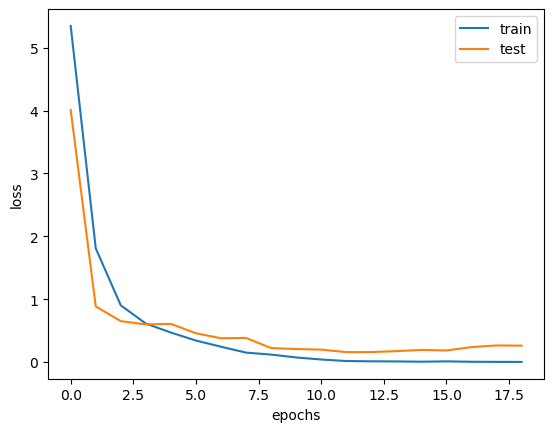

In [87]:
# 시각화 해보기
history.history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.show()

In [88]:
# 평가
model.evaluate(trainData, trainTarget)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 1.0000 - loss: 0.0062


[0.0062485807575285435, 1.0]

In [89]:
model.evaluate(testData, testTarget)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9167 - loss: 0.1570


[0.15703420341014862, 0.9166666865348816]